# Complete Workflow for the Tiffin river basin

This workflow provides a complete working example to develop a simulation campaign for integrated hydrology within ATS.  

It uses the following datasets:

* `NHD Plus` for hydrography.
* `3DEP` for elevation
* `NLCD` for land cover/transpiration/rooting depths
* `MODIS` for LAI
* `GLYHMPS` geology data for structural formations
* `Pelletier` for depth to bedrock and soil texture information
* `SSURGO` for soil data, where available, in the top 2m.

Given some basic inputs (in the next cell) including a NAME, this workflow creates the following files, all of which will reside in output_data:

* Mesh file: `Upper_Maumee.exo`, includes all labeled sets
* Forcing: DayMet data -- daily raster of precip, RH, incoming radiation, etc.
  - `Upper_Maumee_daymet_2010_2011.h5`, the DayMet data on this watershed
  - `Upper_Maumee_daymet_CyclicSteadystate.h5`, a "typical year" of DayMet, smoothed for spinup purposes, then looped certain number of years
* Forcing: LAI data -- every 4 days, time series by land cover type of LAI.
  - `Upper_Maumee_LAI_MODIS_transient.h5`, the LAI, interpolated and smoothed from the raw MODIS data
  - `Upper_Maumee_LAI_MODIS_CyclicSteadystate.h5`, a "typical year" of LAI, smoothed for spinup purposes then looped 10 years
* ATS Input files for three runs, intended to be run sequentially:
  - `Upper_Maumee_steadystate.xml` the steady-state solution based on uniform application of mean rainfall rate
  - `Upper_Maumee_cyclic_steadystate.xml` the cyclic steady state based on typical years
  - `Upper_Maumee_transient.xml` the forward model, run from 2010 -- 2011


In [1]:
# these can be turned on for development work
%load_ext autoreload
%autoreload 2

In [2]:
# setting up logging first or else it gets preempted by another package
import watershed_workflow.ui
watershed_workflow.ui.setup_logging(1)

In [3]:
import os
import sys
import logging
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm as pcm
import shapely
import pandas as pd
import geopandas as gpd
import cftime, datetime
pd.options.display.max_columns = None
import pickle
import shapely.geometry as sg
from shapely.geometry import Point
from shapely.geometry import Polygon
from shapely import force_2d
from shapely.ops import unary_union
import ipympl

import xarray as xr
import plotly.graph_objects as go

import plotly.graph_objects as go
from plotly.subplots import make_subplots

## provide paths to relevant packages for mesh and input file generation 
# Set paths to relevant packages for mesh and input file generation
# Update these paths to match your local installation
#
#sys.path.append('/path/to/seacas/lib')
#%set_env AMANZI_SRC_DIR=/path/to/amanzi
#%set_env ATS_SRC_DIR=/path/to/amanzi/src/physics/ats
#sys.path.append('/path/to/amanzi/tools/amanzi_xml')

# sys.path.append('/Users/5n8/Documents/watershed-workflow/seacas/lib')
# %env AMANZI_SRC_DIR=/Users/5n8/Documents/ats/amanzi-ats/
# %env ATS_SRC_DIR=/Users/5n8/Documents/ats/amanzi-ats/src/physics/ats
# sys.path.append('/Users/5n8/Documents/ats/amanzi-ats/tools/amanzi_xml')

# 1. Set environment variables BEFORE importing any ATS modules
os.environ["AMANZI_SRC_DIR"] = "/Users/5n8/Documents/ats/amanzi-ats"
os.environ["ATS_SRC_DIR"] = "/Users/5n8/Documents/ats/amanzi-ats/src/physics/ats"

# 2. Append system paths
sys.path.append("/Users/5n8/Documents/watershed-workflow/seacas/lib")
sys.path.append("/Users/5n8/Documents/ats/amanzi-ats/tools/amanzi_xml")

import watershed_workflow 
import watershed_workflow.config
import watershed_workflow.sources
import watershed_workflow.utils
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.regions
import watershed_workflow.meteorology
import watershed_workflow.land_cover_properties
import watershed_workflow.resampling
import watershed_workflow.condition
import watershed_workflow.io
import watershed_workflow.sources.standard_names as names
import watershed_workflow.split_hucs
import watershed_workflow.regions

import ats_input_spec
import ats_input_spec.public
import ats_input_spec.io

import amanzi_xml.utils.io as aio
import amanzi_xml.utils.search as asearch
import amanzi_xml.utils.errors as aerrors

# set the default figure size for notebooks
plt.rcParams["figure.figsize"] = (8, 6)


## Input: Parameters and other source data

Note, this section will need to be modified for other runs of this workflow in other regions.

In [4]:
# Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed.
name = 'Tiffin_river' # name the domain, used in filenames, etc
hucs = ['04100006'] # a list of HUCs to run
huc_level = 12 # if provided, an int setting the level at which to include HUC boundaries

# geometric parameters
simplify = 100 # length scale to target average edge
simplify_rivers = 100
stream_outlet_width = 500 # half-width to track a labeled set on which to get discharge
ignore_small_rivers = 2 # ignore rivers which have this or fewer reaches.  likely they are irrigation ditches
                        # or other small features which make things complicated but likely don't add much value
prune_by_area_fraction = 0.002 # ignore reaches whose accumulated catchment area is less than this fraction of the
                              # full domain's area
prune_by_area_fraction_waterbodies = None
num_smoothing_sweeps = 5 # number of times to smooth the DEM prior to elevating


# triangle refinement control
include_rivers = True
refine_d0 = 100
refine_d1 = 500
# refine_A0 = 8000
# refine_A1 = 50000

refine_L0 = 125
refine_L1 = 300

refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2

# # soil structure
# use_geologic_layer = True

# # logistics
# generate_plots = True # plots take time to make and aren't always needed
# generate_daymet = True # potentially don't do Met data forcing
# generate_modis = True

log_to_file = False  # if true, write to file instead of in the notebook output
figsize = (6,6)
figsize_3d = (8,6)

# Simulation control
# - note that we use the NoLeap calendar, same as DayMet.  Simulations are typically run over the "water year"
#   which starts August 1.
start = cftime.DatetimeNoLeap(2010,8,1)
end = cftime.DatetimeNoLeap(2014,8,1)

nyears_cyclic_steadystate = 4   # how many years to run spinup

# Global Soil Properties
min_porosity = 0.05 # minimum porosity considered "too small"
max_permeability = 1.e-10 # max value considered "too permeable"
max_vg_alpha = 1.e-3 # max value of van Genuchten's alpha -- our correlation is not valid for some soils


In [5]:
# a dictionary of outputs -- will include all filenames generated
outputs = {}

In [6]:
# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.default_crs

## Sources and setup

Next we set up the source watershed and coordinate system and all data sources for our mesh.  We will use the CRS that is included in the shapefile.

In [7]:
logging.info("")
logging.info(f"Meshing shape: {hucs}")
logging.info("="*30)


2026-09-03 15:38:13,059 - root - INFO: 
2026-09-03 15:38:13,060 - root - INFO: Meshing shape: ['04100006']
2026-09-03 15:38:13,060 - root - INFO: ==============================


In [8]:
print("Loading custom watershed boundary...")

# Read the custom GeoPackage
custom_huc_gdf = gpd.read_file('/Users/5n8/Documents/Research_topics/2026_ATS/Maumee_river_basin/Subbasin0006_Scott/maumee_watershed_boundary_repaired.gpkg')


Loading custom watershed boundary...


In [9]:
reaches_mod = gpd.read_file('/Users/5n8/Documents/Research_topics/2026_ATS/Maumee_river_basin/Subbasin0006_Scott/maumee_simplified_rivers_repaired_Scott.gpkg')

A wide range of data sources are available; here we use the defaults except for using NHD Plus for watershed boundaries and hydrography (the default is NHD, which is lower resolution and therefore smaller download sizes).

In [10]:
# # set up a dictionary of source objects
sources = watershed_workflow.sources.getDefaultSources()
# sources['hydrography'] = watershed_workflow.sources.hydrography_sources['NHDPlus MR v2.1']
# sources['HUC'] = watershed_workflow.sources.huc_sources['WaterData WBD']
# watershed_workflow.sources.logSources(sources)

## Basin Geometry

In this section, we choose the basin, the streams to be included in the stream-aligned mesh, and make sure that all are resolved discretely at appropriate length scales for this work.

### the Watershed

Note the internal boundaries in the domain for subwatersheds.

In [11]:
# # load the huc
# sources['HUC'].setLevel(huc_level)
# my_hucs = sources['HUC'].getShapesByID(hucs, out_crs=crs)
watershed = watershed_workflow.split_hucs.SplitHUCs(custom_huc_gdf)
watershed.plot()


2026-09-03 15:38:13,246 - root - INFO: Removing holes on 27 polygons
2026-09-03 15:38:13,247 - root - INFO:   -- removed interior
2026-09-03 15:38:13,277 - root - INFO:   -- union
2026-09-03 15:38:13,278 - root - INFO: Parsing 1 components for holes
2026-09-03 15:38:13,278 - root - INFO: Found a little hole: area = 1.183529718673526e-09 at POINT (959395.610689338 2159865.015144653)
2026-09-03 15:38:13,279 - root - INFO:   -- complete


<Axes: >

## the Rivers 

In [12]:
# # download/collect the river network within that shape's bounds
# reaches = sources['hydrography'].getShapesByGeometry(watershed.exterior, crs, out_crs=crs)
# list(reaches.keys())

In [13]:
list(reaches_mod.keys())

['comid',
 'fdate',
 'resolution',
 'gnis_id',
 'reachcode',
 'flowdir',
 'wbareacomi',
 'ftype',
 'fcode',
 'shape_length',
 'streamleve',
 'streamcalc',
 'fromnode',
 'tonode',
 'levelpathi',
 'pathlength',
 'terminalpa',
 'arbolatesu',
 'startflag',
 'terminalfl',
 'dnlevel',
 'uplevelpat',
 'dnlevelpat',
 'dnminorhyd',
 'dndraincou',
 'frommeas',
 'tomeas',
 'rtndiv',
 'vpuin',
 'vpuout',
 'divdasqkm',
 'tidal',
 'totma',
 'wbareatype',
 'pathtimema',
 'hwnodesqkm',
 'maxelevraw',
 'minelevraw',
 'maxelevsmo',
 'minelevsmo',
 'slope',
 'elevfixed',
 'hwtype',
 'slopelenkm',
 'qa_ma',
 'va_ma',
 'qc_ma',
 'vc_ma',
 'qe_ma',
 've_ma',
 'qa_01',
 'va_01',
 'qc_01',
 'vc_01',
 'qe_01',
 've_01',
 'qa_02',
 'va_02',
 'qc_02',
 'vc_02',
 'qe_02',
 've_02',
 'qa_03',
 'va_03',
 'qc_03',
 'vc_03',
 'qe_03',
 've_03',
 'qa_04',
 'va_04',
 'qc_04',
 'vc_04',
 'qe_04',
 've_04',
 'qa_05',
 'va_05',
 'qc_05',
 'vc_05',
 'qe_05',
 've_05',
 'qa_06',
 'va_06',
 'qc_06',
 'vc_06',
 'qe_06',
 've_

In [14]:
# from the generic linestrings, connect them to form trees
rivers = watershed_workflow.river_tree.createRivers(reaches_mod, method='geometry')
# rivers = [rivers[4]] ### Removing the 1 to 3 rivers that are not so useful for the simulation.  The main river is the Maumee, and the other rivers are small tributaries that are not as important for the simulation.
watershed_orig, rivers_orig = watershed, rivers

In [15]:
def plot(ws, rivs, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    ws.plot(color='k', marker='+', markersize=10, ax=ax)
    for river in rivs:
        river.plot(marker='x', markersize=10, ax=ax)


plot(watershed, rivers)


In [16]:
# keeping the originals for plotting comparisons
def createCopy(watershed_mod, rivers):
    """To compare before/after, we often want to create copies.  Note in real workflows most things are done in-place without copies."""
    return watershed.deepcopy(), [r.deepcopy() for r in rivers]


In [17]:
## Pruning   
watershed, rivers = createCopy(watershed_orig, rivers_orig)

prune_by_area_fraction = 0.005
# prune
rivers = watershed_workflow.reduceRivers(rivers, 
                                         prune_by_area=prune_by_area_fraction * watershed.exterior.area/1e6,
                                         remove_diversions=True,
                                         remove_braided_divergences=True)



2026-09-03 15:38:14,119 - root - INFO: Removing rivers with area < 10.069953529294118
2026-09-03 15:38:14,119 - root - INFO:  ... removed 0 rivers
2026-09-03 15:38:14,120 - root - INFO: Removing divergent sections...
2026-09-03 15:38:14,121 - root - INFO:   ... removed 0 divergence tributaries with 0 total reaches.
2026-09-03 15:38:14,124 - root - INFO: ... pruned 0 of 314


In [18]:
# simplifying 
watershed_workflow.simplify(watershed, rivers, 80, 200, 120, 500, min_angle=1, junction_min_angle=1, snap_triple_junctions_tol=80)

# greatly shrunk the rivers... shrink the dataframe too
for river in rivers:
    river.resetDataFrame()

# # Now that the river network is set, find the watershed boundary outlets
# for river in rivers:
#     watershed_workflow.hydrography.findOutletsByCrossings(watershed, river)

2026-09-03 15:38:14,225 - root - INFO: 
2026-09-03 15:38:14,226 - root - INFO: Simplifying
2026-09-03 15:38:14,226 - root - INFO: ------------------------------
2026-09-03 15:38:14,226 - root - INFO: EPSG:5070
2026-09-03 15:38:14,226 - root - INFO: Presimplify to remove colinear, coincident points.
2026-09-03 15:38:14,243 - root - INFO: EPSG:5070
2026-09-03 15:38:14,243 - root - INFO: Pruning leaf reaches < 80
2026-09-03 15:38:14,245 - root - INFO: EPSG:5070
2026-09-03 15:38:14,245 - root - INFO: Merging internal reaches < 80
2026-09-03 15:38:14,248 - root - INFO:   ...cleaned inner linestring of length 42.9391 at centroid (970247.9892983647, 2135152.4919539467) with id '15662144a'
2026-09-03 15:38:14,251 - root - INFO:   ...cleaned inner linestring of length 21.8834 at centroid (958319.0961912342, 2157892.195874949) with id '15661388b'
2026-09-03 15:38:14,253 - root - INFO: EPSG:5070
2026-09-03 15:38:14,261 - root - INFO:   reach: min seg length: 	    7.3108659127 	min geom length: 	 

In [19]:
plot(watershed, rivers)

In [20]:
rivers[0].df.plot(column='bankfull_width', legend=True)

<Axes: >

2026-09-03 15:38:21,644 - root - INFO: Crossings by Polygon:
2026-09-03 15:38:21,645 - root - INFO:   Polygon 0
2026-09-03 15:38:21,645 - root - INFO:     crossing: [ 967565.31180666 2130963.09100509]
2026-09-03 15:38:21,645 - root - INFO:     crossing: [ 970235.21941195 2135135.23300645]
2026-09-03 15:38:21,645 - root - INFO:   Polygon 1
2026-09-03 15:38:21,645 - root - INFO:     crossing: [ 962454.84166876 2122064.39929753]
2026-09-03 15:38:21,646 - root - INFO:     crossing: [ 964637.2433159  2125716.14902135]
2026-09-03 15:38:21,646 - root - INFO:   Polygon 2
2026-09-03 15:38:21,646 - root - INFO:     crossing: [ 958302.29412877 2157904.57708247]
2026-09-03 15:38:21,646 - root - INFO:     crossing: [ 955390.01939158 2167196.5234459 ]
2026-09-03 15:38:21,647 - root - INFO:   Polygon 3
2026-09-03 15:38:21,647 - root - INFO:     crossing: [ 959604.26011362 2105941.95308556]
2026-09-03 15:38:21,647 - root - INFO:   Polygon 4
2026-09-03 15:38:21,647 - root - INFO:     crossing: [ 964976

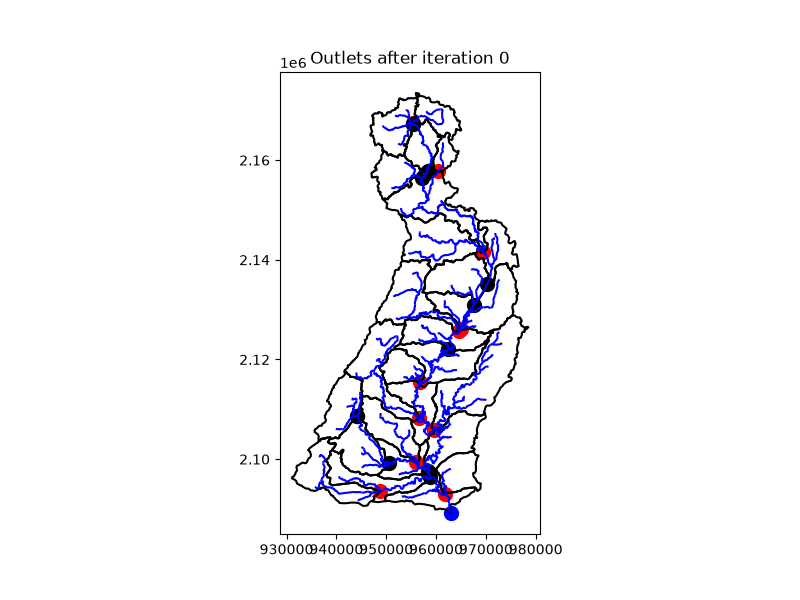

2026-09-03 15:38:21,752 - root - INFO: Iteration = 1
2026-09-03 15:38:21,752 - root - INFO: -----------------
2026-09-03 15:38:21,752 - root - INFO:  poly outlet 5 : 19, [ 958804.61108292 2096492.0474697 ]
2026-09-03 15:38:21,753 - root - INFO:  poly inlet 16 : 19, [ 958804.61108292 2096492.0474697 ]


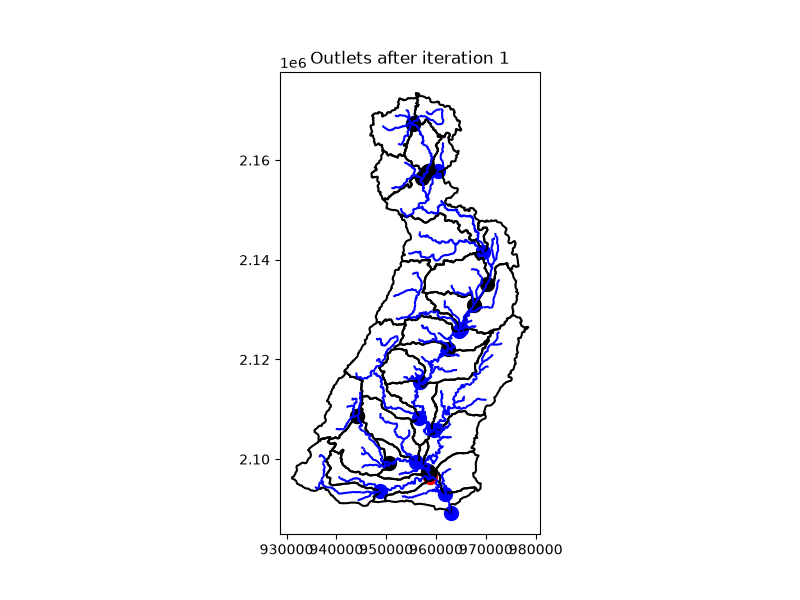

2026-09-03 15:38:21,814 - root - INFO: Iteration = 2
2026-09-03 15:38:21,814 - root - INFO: -----------------
2026-09-03 15:38:21,815 - root - INFO: last outlet is 19 in polygon 5 at {crossings_clusters_centroids[last_outlet]}


ValueError: Length of values (15) does not match length of index (27)

In [21]:
# Now that the river network is set, find the watershed boundary outlets

# dem = sources['DEM'].getDataset(watershed.exterior, watershed.crs)['dem']
for river in rivers:
    watershed_workflow.hydrography.findOutletsByCrossings(watershed, river, tol=10, debug_plot=True)
    # watershed_workflow.hydrography.findOutletsByHydroseq(watershed, river)

In [22]:
print("Bypassing corrupted Hydroseq values. Extracting downstream outlets geometrically...")

# Map the downstream topology (tree depth) for every reach using the .parent attribute!
# The ultimate outlet reach (root) has no parent. Headwaters (leaves) have the highest depth.
for reach in river.preOrder():
    if reach.parent is None:
        reach.properties['tree_depth'] = 0
    else:
        # Upstream branches get a depth of 1 + their downstream parent's depth
        reach.properties['tree_depth'] = reach.parent.properties['tree_depth'] + 1

outlets_list = []

# Iterate through all 27 subbasins
for i, poly in enumerate(watershed.df.geometry):
    subbasin_exits = []
    
    for reach in river.preOrder():
        line = reach.linestring
        
        # Find where the river crosses the subbasin perimeter
        if poly.exterior.intersects(line):
            intersection = poly.exterior.intersection(line)
            
            # Safely extract the crossing points
            if isinstance(intersection, shapely.geometry.Point):
                pts = [intersection]
            elif isinstance(intersection, shapely.geometry.MultiPoint):
                pts = list(intersection.geoms)
            else:
                pts = [Point(p) for p in intersection.coords] if hasattr(intersection, 'coords') else []
            
            # Tag each crossing with its tree depth and its distance to the end of the reach.
            for pt in pts:
                dist_to_end = pt.distance(Point(line.coords[-1]))
                subbasin_exits.append((reach.properties['tree_depth'], dist_to_end, pt))

    if subbasin_exits:
        # Sort primarily by lowest tree depth (closest to domain outlet), 
        # and secondarily by shortest distance to the end of the local reach.
        subbasin_exits.sort(key=lambda x: (x[0], x[1]))
        chosen_outlet = Point(subbasin_exits[0][2].x, subbasin_exits[0][2].y)
    else:
        # Safe fallback if a subbasin has no crossings at all
        chosen_outlet = Point(river.linestring.coords[-1])

    outlets_list.append(chosen_outlet)

# Inject directly into the Pandas DataFrame to guarantee exact length matching (27 rows)
watershed.df['outlet'] = outlets_list
watershed.df['OUTLET'] = outlets_list
watershed.exterior_outlet = Point(river.linestring.coords[-1])

print(f"Successfully mapped {len(outlets_list)} downstream outlets based on tree topology!")

Bypassing corrupted Hydroseq values. Extracting downstream outlets geometrically...
Successfully mapped 27 downstream outlets based on tree topology!


In [23]:
watershed.exterior_outlet = shapely.geometry.Point(rivers[0].linestring.coords[-1])

In [24]:
# this should generate a zoomable map, showing different reaches and watersheds, 
# with discrete points.  Problem areas are clickable to get IDs for manual
# modifications.
m = None
m = watershed.explore(m=m, marker=False)

for river in rivers_orig:
    m = river.explore(m=m, column=None, color='black', name=river['name']+' raw', marker=False)
for river in rivers:
    #m = river.df.explore(m=m)
    m = river.explore(m=m)
    
m = watershed_workflow.makeMap(m)
m

KWARGS:
{'tooltip': False, 'popup': ['ID', 'name', 'huc', 'tohuc', 'area', 'hutype', 'states', 'tnmid'], 'legend': True, 'style_kwds': {'weight': 5}, 'highlight_kwds': {'fillOpacity': 0.4}}


### Mesh Geometry

Discretely create the stream-aligned mesh.  Download elevation data, and condition the mesh discretely to make for better topography.

In [25]:
# # if loading from checkpoint, skip the previous subsubsection
# reaches_df = gpd.read_parquet(name+'_rivers.parquet')
# rivers = watershed_workflow.river_tree.createRivers(reaches_df, method='native')

# with open(name+'_watersheds.pickle', 'rb') as fid:
#     watershed = pickle.load(fid)

In [26]:
# how many types of Stream Orders are there
set([r[names.ORDER] for r in rivers[0].preOrder()])

{np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}

2026-09-03 15:40:22,336 - root - INFO: 
2026-09-03 15:40:22,337 - root - INFO: Stream-aligned Meshing
2026-09-03 15:40:22,337 - root - INFO: ------------------------------
2026-09-03 15:40:22,337 - root - INFO: Creating stream-aligned mesh...
2026-09-03 15:40:23,525 - root - INFO:  ... created a mesh with 8773 elements for river 0
2026-09-03 15:40:23,526 - root - INFO: Adjusting HUC to match reaches at outlet
2026-09-03 15:40:23,541 - root - INFO: Adjusting HUC to match reaches at reach 5 and coordinate (961820.6471446493, 2092941.089606982)
2026-09-03 15:40:23,561 - root - INFO: Adjusting HUC to match reaches at reach 14 and coordinate (958804.6110829213, 2096492.0474697002)
2026-09-03 15:40:23,570 - root - INFO: Adjusting HUC to match reaches at reach 18 and coordinate (948806.0300363344, 2093635.7572259237)
2026-09-03 15:40:23,622 - root - INFO: Adjusting HUC to match reaches at reach 39 and coordinate (958301.9285320021, 2097555.3777346252)
2026-09-03 15:40:23,635 - root - INFO: Ad

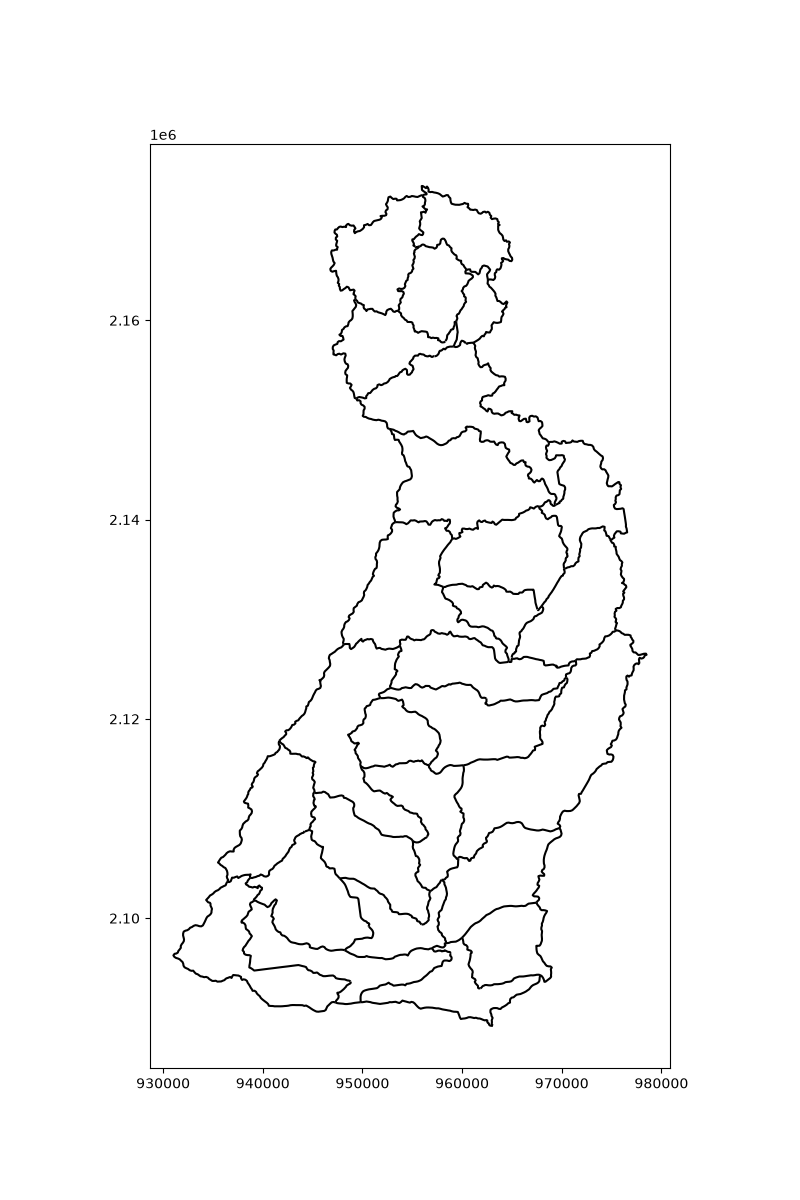

2026-09-03 15:40:24,513 - root - INFO: Building the remaining triangular mesh...
2026-09-03 15:40:24,513 - root - INFO: 
2026-09-03 15:40:24,513 - root - INFO: Triangulation
2026-09-03 15:40:24,513 - root - INFO: ------------------------------
2026-09-03 15:40:24,535 - root - INFO: Triangulating...
2026-09-03 15:40:24,565 - root - INFO:    22316 points and 22365 facets
2026-09-03 15:40:24,565 - root - INFO:  checking graph consistency
2026-09-03 15:40:24,565 - root - INFO:  tolerance is set to 1.0
2026-09-03 15:40:24,614 - root - INFO:  building graph data structures
2026-09-03 15:40:24,654 - root - INFO:  triangle.build...
2026-09-03 15:40:36,663 - root - INFO:   ...built: 67476 mesh points and 115800 triangles
2026-09-03 15:40:36,666 - root - INFO: Plotting triangulation diagnostics
2026-09-03 15:40:40,818 - root - INFO:   min area = 46.5750732421875
2026-09-03 15:40:40,818 - root - INFO:   max area = 44999.60437011719
2026-09-03 15:40:41,464 - root - INFO: Fixing corridor-spanning t

In [27]:
## Triangulation

d0 = refine_d0; d1 = refine_d1
A0 = refine_A0; A1 = refine_A1 

# Refine triangles if they get too acute
min_angle = 20 # degrees

# width of reach by stream order (order:width)
# def widths(reach):
#     mapping = {1: 10, 2: 10, 3: 20, 4: 30}
#     order = reach.properties['stream_order']  # default to 1 if not found
#     return mapping.get(order, 10)  # default width if order not found

# m2, area, dists = watershed_workflow.tessalateRiverAligned(watershed, rivers, river_width=widths,
#                                               refine_min_angle=min_angle, refine_distance=[d0,A0,d1,A1],
#                                               diagnostics=True, debug=True)

def widths_from_data(reach):
    try:
        # Access the _RowView using bracket indexing
        width = float(reach.properties['bankfull_width'])
        
        # Optional: check if the value is NaN (blank in the dataframe)
        import math
        if math.isnan(width):
            return 10.0
            
        return width
    except (KeyError, ValueError, TypeError):
        # Safe fallback if the column is entirely missing or contains invalid data
        return 10.0

m2, area, dists = watershed_workflow.tessalateRiverAligned(watershed, rivers, river_width=widths_from_data,
                                              refine_min_angle=min_angle, refine_distance=[d0,A0,d1,A1],
                                              diagnostics=True, debug=True)

In [28]:
# get a dem dataset and elevate the mesh according to interpolation of those elevations
dem = sources['DEM'].getDataset(watershed.exterior, watershed.crs)['dem']
watershed_workflow.elevate(m2, dem, method='linear')

# note, if this fails, may need to increase the resolution buffer on the manager, by setting
#sources['DEM'].native_resolution = sources['DEM'].native_resolution * 2
assert not any(np.isnan(m2.coords[:,-1]))



2026-09-03 15:44:05,556 - root - INFO: Incoming shape area = 0.2175142778592088
2026-09-03 15:44:05,557 - root - INFO: ... buffering incoming shape by 3x native resolution = 0.00324
2026-09-03 15:44:05,559 - root - INFO: ... buffered shape area = 0.2273075381774495
2026-09-03 15:44:05,559 - root - INFO: ... snapped bounding box = (-84.76056, 41.27544, -84.13956, 42.03792)
2026-09-03 15:44:05,560 - root - INFO: Getting DEM with map of area = 0.2273075381774495


In [29]:
watershed.crs

<Projected CRS: EPSG:5070>
Name: NAD83 / Conus Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - CONUS onshore - Alabama; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming.
- bounds: (-124.79, 24.41, -66.91, 49.38)
Coordinate Operation:
- name: Conus Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

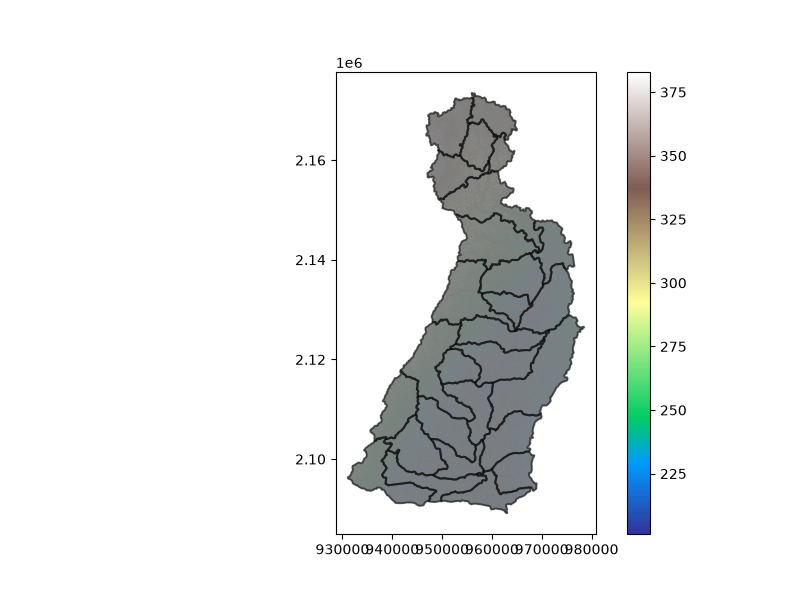

In [30]:
fig, ax = plt.subplots()
m2.plot(facecolors='elevation', ax=ax)
watershed.plot(ax=ax, color='k', alpha=0.5)
plt.show()

In [31]:
# hydrologically condition the mesh, removing pits
river_mask=np.zeros((len(m2.conn)))
for i, elem in enumerate(m2.conn):
    if not len(elem)==3:
        river_mask[i]=1     
# watershed_workflow.condition.fillPitsDual(m2, is_waterbody=river_mask)
# watershed_workflow.condition.fillPits(m2, is_waterbody=river_mask)

There are a range of options to condition river corridor mesh. We hydrologically condition the river mesh, ensuring unimpeded water flow in river corridors by globally adjusting flowlines to rectify artificial obstructions from inconsistent DEM elevations or misalignments. Please read the documentation for more information


In [32]:
# conditioning river mesh
#
# adding elevations to the river tree for stream bed conditioning
watershed_workflow.condition.setProfileByDEM(rivers, dem)

# conditioning the river mesh using NHD elevations
watershed_workflow.condition.conditionRiverMesh(m2, rivers[0])

In [33]:
# add labeled sets for subcatchments and outlets
watershed_workflow.regions.addWatershedAndOutletRegions(m2, watershed, outlet_width=stream_outlet_width, exterior_outlet=True)

# add labeled sets for river corridor cells
watershed_workflow.regions.addRiverCorridorRegions(m2, rivers)

# add labeled sets for river corridor cells by order
watershed_workflow.regions.addStreamOrderRegions(m2, rivers)

2026-09-03 15:44:17,912 - root - INFO: Adding regions for 27 polygons


RuntimeError: Invalid set of boundary edges on mesh -- is the mesh domain simply connected?

In [34]:
### Custom labeling of subbasins and outlets

print("Labeling 27 subbasin...")
watershed_workflow.regions.addPolygonalRegions(m2, watershed, volume=True)

print("Dissolving internal subbasins to find the safe exterior shell...")
unified_poly = unary_union(watershed.df.geometry.tolist())

# Grab the largest contiguous block if it fractured
if hasattr(unified_poly, 'geoms'):
    unified_poly = max(unified_poly.geoms, key=lambda a: a.area)

# ---> THE HOLE-FILLING FIX <---
# Rebuild the polygon using ONLY the outermost perimeter line.
# This permanently deletes any internal micro-gaps or holes!
solid_exterior_poly = Polygon(unified_poly.exterior)

# Use the new solid polygon to build the SplitHUCs object
unified_df = gpd.GeoDataFrame({'geometry': [solid_exterior_poly]}, crs=watershed.crs)
unified_watershed = watershed_workflow.split_hucs.SplitHUCs(unified_df)

# Assign the single ultimate domain outlet
unified_watershed.df['outlet'] = [watershed.exterior_outlet]
unified_watershed.df['name'] = ['domain_exterior']
unified_watershed.df['NAME'] = ['domain_exterior']
unified_watershed.exterior_outlet = watershed.exterior_outlet

import watershed_workflow.mesh
from shapely.geometry import Point, LineString

import collections
import watershed_workflow.mesh
from shapely.geometry import Point, LineString

print("MATHEMATICAL BYPASS: Extracting boundary edges without topology checks...")

# Extract the raw cell connectivity list
if hasattr(m2, '_conn') and m2._conn is not None:
    cells = m2._conn
else:
    cells = m2.cells

# Count how many times every edge appears in the mesh
edge_counts = collections.Counter()

for cell in cells:
    n = len(cell)
    for i in range(n):
        # Sort nodes so (NodeA, NodeB) and (NodeB, NodeA) match
        edge = tuple(sorted((int(cell[i]), int(cell[(i + 1) % n]))))
        edge_counts[edge] += 1

# Any edge that only appears ONCE is a guaranteed boundary edge
raw_bnd_edges = [edge for edge, count in edge_counts.items() if count == 1]
print(f"Extracted {len(raw_bnd_edges)} raw boundary edges via neighbor counting.")

# Get the outlet point and define the search radius
outlet_pt = watershed.exterior_outlet
outlet_radius = stream_outlet_width / 2.0  

domain_boundary_edges = []
outlet_edges = []

# Sort the edges based on their distance to the exact outlet coordinate
for edge in raw_bnd_edges:
    n1 = m2.coords[edge[0]]
    n2 = m2.coords[edge[1]]
    
    edge_line = LineString([n1[:2], n2[:2]])
    dist = edge_line.distance(outlet_pt)
    
    if dist <= outlet_radius:
        outlet_edges.append(edge)
    else:
        domain_boundary_edges.append(edge)

# Safety fallback: If the radius was too small and missed the edge, snap to the absolute closest one
if len(outlet_edges) == 0:
    print("   -> Warning: Outlet radius too small. Snapping to the absolute closest edge!")
    distances = [LineString([m2.coords[e[0]][:2], m2.coords[e[1]][:2]]).distance(outlet_pt) for e in raw_bnd_edges]
    closest_idx = distances.index(min(distances))
    closest_edge = raw_bnd_edges[closest_idx]
    
    outlet_edges.append(closest_edge)
    domain_boundary_edges.remove(closest_edge)

# Inject the sets directly into the mesh exactly how ATS expects them
ls_boundary = watershed_workflow.mesh.LabeledSet(
    'watershed boundary', 
    m2.getNextAvailableLabeledSetID(), 
    'FACE', 
    domain_boundary_edges
)
m2.labeled_sets.append(ls_boundary)

ls_outlet = watershed_workflow.mesh.LabeledSet(
    'watershed outlet', 
    m2.getNextAvailableLabeledSetID(), 
    'FACE', 
    outlet_edges
)
m2.labeled_sets.append(ls_outlet)

print(f"Success! Tagged {len(domain_boundary_edges)} boundary faces and {len(outlet_edges)} outlet faces.")

print("Labeling river corridors...")
watershed_workflow.regions.addRiverCorridorRegions(m2, rivers)
watershed_workflow.regions.addStreamOrderRegions(m2, rivers)

print("All regions successfully labeled!")

2026-09-03 15:44:28,388 - root - INFO: Adding regions for 27 polygons


Labeling 27 subbasin...


2026-09-03 15:44:32,010 - root - INFO: Removing holes on 1 polygons
2026-09-03 15:44:32,011 - root - INFO:   -- removed interior
2026-09-03 15:44:32,011 - root - INFO:   -- union
2026-09-03 15:44:32,011 - root - INFO: Parsing 1 components for holes
2026-09-03 15:44:32,011 - root - INFO:   -- complete


Dissolving internal subbasins to find the safe exterior shell...
MATHEMATICAL BYPASS: Extracting boundary edges without topology checks...
Extracted 1620 raw boundary edges via neighbor counting.
Success! Tagged 1611 boundary faces and 9 outlet faces.
Labeling river corridors...
All regions successfully labeled!


In [35]:
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

10000 : CELL : 4714 : "Deer Creek-Bean Creek"
10001 : CELL : 4714 : "Deer Creek-Bean Creek surface"
10002 : CELL : 4755 : "Bates Creek-Tiffin River"
10003 : CELL : 4755 : "Bates Creek-Tiffin River surface"
10004 : CELL : 2769 : "Round Creek-Bean Creek"
10005 : CELL : 2769 : "Round Creek-Bean Creek surface"
10006 : CELL : 10981 : "Brush Creek"
10007 : CELL : 10981 : "Brush Creek surface"
10008 : CELL : 4850 : "Old Bean Creek"
10009 : CELL : 4850 : "Old Bean Creek surface"
10010 : CELL : 4565 : "Mud Creek"
10011 : CELL : 4565 : "Mud Creek surface"
10012 : CELL : 3306 : "Saint Joseph Creek-Bean Creek"
10013 : CELL : 3306 : "Saint Joseph Creek-Bean Creek surface"
10014 : CELL : 7691 : "Beaver Creek"
10015 : CELL : 7691 : "Beaver Creek surface"
10016 : CELL : 2498 : "Stag Run-Bean Creek"
10017 : CELL : 2498 : "Stag Run-Bean Creek surface"
10018 : CELL : 4983 : "Coon Creek-Tiffin River"
10019 : CELL : 4983 : "Coon Creek-Tiffin River surface"
10020 : CELL : 8328 : "Covell Drain-Bean Creek"
10

There are a range of options to condition river corridor mesh. We hydrologically condition the river mesh, ensuring unimpeded water flow in river corridors by globally adjusting flowlines to rectify artificial obstructions from inconsistent DEM elevations or misalignments. Please read the documentation for more information


## Surface properties

Meshes interact with data to provide forcing, parameters, and more in the actual simulation.  Specifically, we need vegetation type on the surface to provide information about transpiration and subsurface structure to provide information about water retention curves, etc.

### NLCD for LULC

We'll start by downloading and collecting land cover from the NLCD dataset, and generate sets for each land cover type that cover the surface.  Likely these will be some combination of grass, deciduous forest, coniferous forest, and mixed.

In [ ]:
# download the NLCD raster
nlcd = sources['land cover'].getDataset(watershed.exterior.buffer(100), watershed.crs)['cover']

# what land cover types did we get?
logging.info('Found land cover dtypes: {}'.format(nlcd.dtype))
logging.info('Found land cover types: {}'.format(set(list(nlcd.values.ravel()))))

In [ ]:
# create a colormap for the data
nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
      watershed_workflow.colors.createNLCDColormap(np.unique(nlcd))
nlcd_cmap

In [ ]:
fig, ax = plt.subplots(1,1)
nlcd.plot.imshow(ax=ax, cmap=nlcd_cmap, norm=nlcd_norm, add_colorbar=False)
watershed_workflow.colors.createIndexedColorbar(ncolors=len(nlcd_indices), 
                               cmap=nlcd_cmap, labels=nlcd_labels, ax=ax) 
ax.set_title('Land Cover')
plt.show()

In [ ]:
# map nlcd onto the mesh
m2_nlcd = watershed_workflow.getDatasetOnMesh(m2_mod, nlcd, method='nearest')
m2_mod.cell_data["land_cover"] = m2_nlcd

In [ ]:
# double-check that nan not in the values
assert 127 not in m2_nlcd

# create a new set of labels and indices with only those that actually appear on the mesh
nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
      watershed_workflow.colors.createNLCDColormap(np.unique(m2_nlcd))


In [ ]:
mp = m2_mod.plot(facecolors=m2_nlcd, cmap=nlcd_cmap, norm=nlcd_norm, edgecolors=None, colorbar=False)
watershed_workflow.colors.createIndexedColorbar(ncolors=len(nlcd_indices), 
                               cmap=nlcd_cmap, labels=nlcd_labels, ax=plt.gca()) 
plt.show()

In [ ]:
# add labeled sets to the mesh for NLCD
nlcd_labels_dict = dict(zip(nlcd_indices, nlcd_labels))
watershed_workflow.regions.addSurfaceRegions(m2_mod, names=nlcd_labels_dict)

In [ ]:
nlcd_labels_dict

In [ ]:
for ls in m2_mod.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

### MODIS LAI

Leaf area index is needed on each land cover type -- this is used in the Evapotranspiration calculation.

In [ ]:
# download LAI and corresponding LULC datasets -- these are actually already downloaded, 
# as the MODIS AppEEARS API is quite slow
#
# Note that MODIS does NOT work with the noleap calendar, so we have to convert to actual dates first

if 'AppEEARS' not in watershed_workflow.config.rcParams:
    watershed_workflow.config.rcParams['AppEEARS'] = {}

watershed_workflow.config.rcParams['AppEEARS']['username'] = 'username'
watershed_workflow.config.rcParams['AppEEARS']['password'] = 'password'

start_leap = cftime.DatetimeGregorian(start.year, start.month, start.day)
end_leap = cftime.DatetimeGregorian(end.year, end.month, end.day)
res = sources['LAI'].getDataset(watershed.exterior, crs, start_leap, end_leap)


In [ ]:
modis_data = res
assert modis_data['LAI'].rio.crs is not None
print(modis_data['LULC'].rio.crs, modis_data['LULC'].dtype)


In [ ]:
# MODIS data comes with time-dependent LAI AND time-dependent LULC -- just take the mode to find the most common LULC
modis_data['LULC'] = watershed_workflow.data.computeMode(modis_data['LULC'], 'time_LULC')

# now it is safe to have only one time
modis_data = modis_data.rename({'time_LAI':'time'})

# remove leap day (366th day of any leap year) to match our Noleap Calendar
modis_data = watershed_workflow.data.filterLeapDay(modis_data)

In [ ]:
# plot the MODIS data -- note the entire domain is covered with one type for Coweeta (it is small!)
modis_data['LULC'].plot.imshow()

In [ ]:
# compute the transient time series
modis_lai = watershed_workflow.land_cover_properties.computeTimeSeries(modis_data['LAI'], modis_data['LULC'], 
                                                                      polygon=watershed.exterior, polygon_crs=watershed.crs)

In [ ]:
modis_lai

In [ ]:
modis_lai_smoothed = watershed_workflow.data.smoothTimeSeries(modis_lai, 'time')
modis_lai_typical = watershed_workflow.data.computeAverageYear(modis_lai_smoothed, start_date=2000, output_nyears=10, time_column='time')
watershed_workflow.land_cover_properties.plotLAI(modis_lai_typical, indices='MODIS')

# compute a typical year
# modis_lai_typical = watershed_workflow.data.computeAverageYear(modis_lai_smoothed, 'time', output_nyears=10, 
#                                                                   start_year=2000)

outputs['modis_lai_cyclic_steadystate'] = os.path.join(f'{name}_LAI_MODIS_CyclicSteadystate.h5')
watershed_workflow.io.writeTimeseriesToHDF5(outputs['modis_lai_cyclic_steadystate'], modis_lai_typical)
watershed_workflow.land_cover_properties.plotLAI(modis_lai_typical, indices='MODIS')

In [ ]:
# smooth the data in time
modis_lai_smoothed = watershed_workflow.data.smoothTimeSeries(modis_lai, 'time')

# save the MODIS time series to disk
outputs['modis_lai_transient'] = os.path.join(f'{name}_LAI_MODIS_transient.h5')
watershed_workflow.io.writeTimeseriesToHDF5(outputs['modis_lai_transient'], modis_lai_smoothed)
watershed_workflow.land_cover_properties.plotLAI(modis_lai_smoothed, indices='MODIS')

### Crosswalk of LAI to NLCD LC

In [ ]:
crosswalk = watershed_workflow.land_cover_properties.computeCrosswalk(modis_data['LULC'], nlcd, method='fractional area')

In [ ]:
# Compute the NLCD-based time series
nlcd_lai_cyclic_steadystate = watershed_workflow.land_cover_properties.applyCrosswalk(crosswalk, modis_lai_typical)
nlcd_lai_transient = watershed_workflow.land_cover_properties.applyCrosswalk(crosswalk, modis_lai_smoothed)

watershed_workflow.land_cover_properties.removeNullLAI(nlcd_lai_cyclic_steadystate)
watershed_workflow.land_cover_properties.removeNullLAI(nlcd_lai_transient)
nlcd_lai_transient

In [ ]:
# write the NLCD-based time series to disk
outputs['nlcd_lai_cyclic_steadystate'] = os.path.join(f'{name}_LAI_NLCD_CyclicSteadystate.h5')
watershed_workflow.io.writeTimeseriesToHDF5(outputs['nlcd_lai_cyclic_steadystate'], nlcd_lai_cyclic_steadystate)

outputs['nlcd_lai_transient'] = os.path.join(f'{name}_LAI_NLCD_{start.year}_{end.year}.h5')
watershed_workflow.io.writeTimeseriesToHDF5(outputs['nlcd_lai_transient'], nlcd_lai_transient)

## Subsurface Soil, Geologic Structure

### NRCS Soils

In [ ]:
# get NRCS shapes, on a reasonable crs
nrcs = sources['soil structure'].getShapesByGeometry(watershed.exterior, watershed.crs, out_crs=crs)
nrcs

In [ ]:
### Due to bigger soil domain request, we need to split the geometry into smaller pieces and call the NRCS tool on each piece.  This is because the NRCS tool has a limit on how many features it can return at once. 
### num_divisions can be adjusted to split the geometry into more pieces if needed. num_divisions 4 will create a 4x4 grid of sub-boxes.
def split_geometry_into_grid(geometry, num_divisions=4):
    """Splits a large geometry bounding box into a smaller grid of sub-boxes."""
    minx, miny, maxx, maxy = geometry.bounds
    
    # Create grid lines
    x_coords = np.linspace(minx, maxx, num_divisions + 1)
    y_coords = np.linspace(miny, maxy, num_divisions + 1)
    
    chunks = []
    # Build smaller bounding box polygons
    for i in range(num_divisions):
        for j in range(num_divisions):
            box = sg.box(x_coords[i], y_coords[j], x_coords[i+1], y_coords[j+1])
            # Only keep the chunk if it actually overlaps your watershed
            if geometry.intersects(box):
                chunks.append(geometry.intersection(box))
                
    return chunks

# 1. Split your watershed exterior into smaller pieces
# Adjust num_divisions higher (e.g., 4x4 = 16 chunks) if the area is massive
watershed_chunks = split_geometry_into_grid(watershed.exterior, num_divisions=3)

chunked_shapes = []
for i, chunk_geom in enumerate(watershed_chunks):
    print(f"Processing chunk {i+1} of {len(watershed_chunks)}...")
    try:
        # Call the NRCS tool using the smaller chunk geometry
        chunk_result = sources['soil structure'].getShapesByGeometry(
            chunk_geom, 
            watershed.crs, 
            out_crs=crs
        )
        if chunk_result is not None and not chunk_result.empty:
            chunked_shapes.append(chunk_result)
    except Exception as e:
        print(f"Chunk {i+1} failed: {e}")

# 2. Combine all successful chunks back into one GeoDataFrame
if chunked_shapes:
    nrcs = gpd.pd.concat(chunked_shapes, ignore_index=True)
    # Deduplicate overlapping features if necessary
    nrcs = nrcs.drop_duplicates(subset=['mukey']) 
else:
    print("No data retrieved.")

nrcs

In [ ]:
# create a clean dataframe with just the data we will need for ATS
def replace_column_nans(df, col_nan, col_replacement):
    """In a df, replace col_nan entries by col_replacement if is nan.  In Place!"""
    row_indexer = df[col_nan].isna()
    df.loc[row_indexer, col_nan] = df.loc[row_indexer, col_replacement]
    return

# where poro or perm is nan, put Rosetta poro
replace_column_nans(nrcs, 'porosity [-]', 'Rosetta porosity [-]')
replace_column_nans(nrcs, 'permeability [m^2]', 'Rosetta permeability [m^2]')

# drop unnecessary columns
for col in ['Rosetta porosity [-]', 'Rosetta permeability [m^2]', 'bulk density [g/cm^3]', 'total sand pct [%]',
            'total silt pct [%]', 'total clay pct [%]']:
    nrcs.pop(col)
    
# drop nans
nan_mask = nrcs.isna().any(axis=1)
dropped_mukeys = nrcs.index[nan_mask]

# Drop those rows
nrcs = nrcs[~nan_mask]

assert nrcs['porosity [-]'][:].min() >= min_porosity
assert nrcs['permeability [m^2]'][:].max() <= max_permeability
nrcs

# check for nans
nrcs.isna().any()

In [ ]:
# Compute the soil color of each cell of the mesh
# Note, we use mukey here because it is an int, while ID is a string
soil_color_mukey = watershed_workflow.getShapePropertiesOnMesh(m2_mod, nrcs, 'mukey', 
                                                         resolution=50, nodata=-999)

nrcs.set_index('mukey', drop=False, inplace=True)

unique_soil_colors = list(np.unique(soil_color_mukey))
if -999 in unique_soil_colors:
    unique_soil_colors.remove(-999)

# retain only the unique values of soil_color
nrcs = nrcs.loc[unique_soil_colors]

# renumber the ones we know will appear with an ATS ID using ATS conventions
nrcs['ATS ID'] = range(1000, 1000+len(unique_soil_colors))
nrcs.set_index('ATS ID', drop=True, inplace=True)

# create a new soil color and a soil thickness map using the ATS IDs
soil_color = -np.ones_like(soil_color_mukey)
soil_thickness = np.nan * np.ones(soil_color.shape, 'd')

for ats_ID, ID, thickness in zip(nrcs.index, nrcs.mukey, nrcs['thickness [m]']):
    mask = np.where(soil_color_mukey == ID)
    soil_thickness[mask] = thickness
    soil_color[mask] = ats_ID

m2_mod.cell_data['soil_color'] = soil_color
m2_mod.cell_data['soil thickness'] = soil_thickness


In [ ]:
# plot the soil color
# -- get a cmap for soil color
sc_indices, sc_cmap, sc_norm, sc_ticks, sc_labels = \
      watershed_workflow.colors.createIndexedColormap(nrcs.index)

mp = m2_mod.plot(facecolors=m2_mod.cell_data['soil_color'], cmap=sc_cmap, norm=sc_norm, edgecolors=None, colorbar=False)
watershed_workflow.colors.createIndexedColorbar(ncolors=len(nrcs), 
                               cmap=sc_cmap, labels=sc_labels, ax=plt.gca()) 
plt.show()

In [ ]:
nrcs

### Depth to Bedrock from SoilGrids

In [ ]:
dtb = sources['depth to bedrock'].getDataset(watershed.exterior, watershed.crs)['band_1']

# # the SoilGrids dataset is in cm --> convert to meters
# dtb.values = dtb.values/100.

# average_soil_and_sedimentary-deposit_thickness from Pelletier data is in m
dtb.values = dtb.values

"""
Note: This example uses ManagerRaster to process the given SoilGrids file - dtb_file, so unit conversion is needed here.
If using ManagerSoilGrids2017 to automatically download and process SoilGrids file, the manager code will do the conversion
internally. For instance:

(1) Using ManagerRaster in this example:
sources['depth to bedrock'] = watershed_workflow.sources.ManagerRaster(dtb_file)
dtb = sources['depth to bedrock'].getDataset(watershed.exterior, watershed.crs)['band_1']
dtb.values = dtb.values/100. # convert cm to m

(2) Using ManagerSoilGrids2017:
sources['depth to bedrock'] = watershed_workflow.sources.ManagerSoilGrids2017('SoilGrids2017_US')
dtb = sources['depth to bedrock'].getDataset(watershed.exterior, watershed.crs)['BDTICM']
# dtb.values is in m.
"""


In [ ]:
# map to the mesh
m2_mod.cell_data['dtb'] = watershed_workflow.getDatasetOnMesh(m2_mod, dtb, method='linear')


In [ ]:
gons = m2_mod.plot(facecolors=m2_mod.cell_data['dtb'], cmap='RdBu', edgecolors=None)
plt.show()

### GLHYMPs Geology

In [ ]:
glhymps = sources['geologic structure'].getShapesByGeometry(watershed.exterior.buffer(1000), watershed.crs, out_crs=crs)
glhymps = watershed_workflow.soil_properties.mangleGLHYMPSProperties(glhymps,
                                              min_porosity=min_porosity, 
                                              max_permeability=max_permeability, 
                                              max_vg_alpha=max_vg_alpha)

# intersect with the buffered geometry -- don't keep extras
glhymps = glhymps[glhymps.intersects(watershed.exterior.buffer(100))]
glhymps

In [ ]:
# quality check -- make sure glymps shapes cover the watershed
print(glhymps.union_all().contains(watershed.exterior))
glhymps

In [ ]:
# clean the data
glhymps.pop('logk_stdev [-]')

assert glhymps['porosity [-]'][:].min() >= min_porosity
assert glhymps['permeability [m^2]'][:].max() <= max_permeability
assert glhymps['van Genuchten alpha [Pa^-1]'][:].max() <= max_vg_alpha

glhymps.isna().any()

In [ ]:
# note that for larger areas there are often common regions -- two labels with the same properties -- no need to duplicate those with identical values.
def reindex_remove_duplicates(df, index):
    """Removes duplicates, creating a new index and saving the old index as tuples of duplicate values. In place!"""
    if index is not None:
        if index in df:
            df.set_index(index, drop=True, inplace=True)
    
    index_name = df.index.name

    # identify duplicate rows
    duplicates = list(df.groupby(list(df)).apply(lambda x: tuple(x.index)))

    # order is preserved
    df.drop_duplicates(inplace=True)
    df.reset_index(inplace=True)
    df[index_name] = duplicates
    return

reindex_remove_duplicates(glhymps, 'ID')
glhymps

In [ ]:
# Compute the geo color of each cell of the mesh
geology_color_glhymps = watershed_workflow.getShapePropertiesOnMesh(m2, glhymps, 'index', 
                                                         resolution=50, nodata=-999)

# retain only the unique values of geology that actually appear in our cell mesh
unique_geology_colors = list(np.unique(geology_color_glhymps))
if -999 in unique_geology_colors:
    unique_geology_colors.remove(-999)

# retain only the unique values of geology_color
glhymps = glhymps.loc[unique_geology_colors]

# renumber the ones we know will appear with an ATS ID using ATS conventions
glhymps['ATS ID'] = range(100, 100+len(unique_geology_colors))
glhymps['TMP_ID'] = glhymps.index
glhymps.reset_index(drop=True, inplace=True)
glhymps.set_index('ATS ID', drop=True, inplace=True)

# create a new geology color using the ATS IDs
geology_color = -np.ones_like(geology_color_glhymps)
for ats_ID, tmp_ID in zip(glhymps.index, glhymps.TMP_ID):
    geology_color[np.where(geology_color_glhymps == tmp_ID)] = ats_ID

glhymps.pop('TMP_ID')

m2.cell_data['geology_color'] = geology_color
                            

In [ ]:
geology_color_glhymps.min()

### Combine to form a complete subsurface dataset

In [ ]:
bedrock = watershed_workflow.soil_properties.getDefaultBedrockProperties()

# merge the properties databases
# subsurface_props = pd.concat([glhymps, nrcs, bedrock]) # GLHYMPS data were removed to keep the soil and bedrock layers only as GLHYMPS porosity and VG alpha are mostly NaNs and soil thickness are high in these areas
subsurface_props = pd.concat([nrcs, bedrock])

# save the properties to disk for use in generating input file
outputs['subsurface_properties'] = os.path.join(f'{name}_subsurface_properties.csv')
subsurface_props.to_csv(outputs['subsurface_properties'])
subsurface_props = subsurface_props.reset_index()
subsurface_props


## Extrude the 2D Mesh to make a 3D mesh

In [ ]:
# set the floor of the domain as max DTB
dtb_max = np.nanmax(m2.cell_data['dtb'].values)
m2.cell_data['dtb'] = m2.cell_data['dtb'].fillna(dtb_max)

print(f'total thickness: {dtb_max} m')
total_thickness = 50.


In [ ]:
# Generate a dz structure for the top 2m of soil
#
# here we try for 10 cells, starting at 5cm at the top and going to 50cm at the bottom of the 2m thick soil
dzs, res = watershed_workflow.mesh.optimizeDzs(0.05, 0.5, 2, 10)
print(dzs)
print(sum(dzs))

In [ ]:
# this looks like it would work out, with rounder numbers:
dzs_soil = [0.05, 0.05, 0.05, 0.12, 0.23, 0.5, 0.5, 0.5]
print(sum(dzs_soil))

In [ ]:
# 50m total thickness, minus 2m soil thickness, leaves us with 48 meters to make up.
# optimize again...
dzs2, res2 = watershed_workflow.mesh.optimizeDzs(1, 10, 48, 8)
print(dzs2)
print(sum(dzs2))

# how about...
dzs_geo = [1.0, 2.0, 4.0, 8.0, 11, 11, 11]
print(dzs_geo)
print(sum(dzs_geo))

In [ ]:
# layer extrusion
DTB = m2.cell_data['dtb'].values
soil_color = m2.cell_data['soil_color'].values
# geo_color = m2.cell_data['geology_color'].values     # not required after removing GLHYMPS data
soil_thickness = m2.cell_data['soil thickness'].values

# -- data structures needed for extrusion
layer_types = []
layer_data = []
layer_ncells = []
layer_mat_ids = []

# -- soil layer --
depth = 0
for dz in dzs_soil:
    depth += 0.5 * dz
    layer_types.append('constant')
    layer_data.append(dz)
    layer_ncells.append(1)
    
    # use glhymps params
    br_or_geo = np.where(depth < DTB, soil_color, 999)    # geo_color changed to soil_color as GLHYMPS data were removed to keep the soil and bedrock layers only
    soil_or_br_or_geo = np.where(np.bitwise_and(soil_color > 0, depth < soil_thickness),
                                 soil_color,
                                 br_or_geo)

    layer_mat_ids.append(soil_or_br_or_geo)
    depth += 0.5 * dz
    
# # -- geologic layer --
# for dz in dzs_geo:
#     depth += 0.5 * dz
#     layer_types.append('constant')
#     layer_data.append(dz)
#     layer_ncells.append(1)
#     geo_or_br = np.where(depth < DTB, soil_color, 999)   # geo_color changed to soil_color as GLHYMPS data were removed to keep the soil and bedrock layers only
#     layer_mat_ids.append(geo_or_br)
#     depth += 0.5 * dz

# print the summary
watershed_workflow.mesh.Mesh3D.summarizeExtrusion(layer_types, layer_data, 
                                            layer_ncells, layer_mat_ids)
# downselect subsurface properties to only those that are used
layer_mat_id_used = list(np.unique(np.array(layer_mat_ids)))
layer_mat_id_used = [int(x) for x in layer_mat_id_used]
subsurface_props_used = subsurface_props.set_index('ATS ID').reindex(layer_mat_id_used)
# subsurface_props_used = subsurface_props.loc[layer_mat_id_used]
subsurface_props_used


In [ ]:
subsurface_props

In [ ]:
layer_mat_ids

In [ ]:
# extrude
m3 = watershed_workflow.mesh.Mesh3D.extruded_Mesh2D(m2, layer_types, layer_data, 
                                             layer_ncells, layer_mat_ids)

In [ ]:
print('2D labeled sets')
print('---------------')
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('')
print('Extruded 3D labeled sets')
print('------------------------')
for ls in m3.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('')
print('Extruded 3D side sets')
print('---------------------')
for ls in m3.side_sets:
    print(f'{ls.setid} : FACE : {len(ls.cell_list)} : "{ls.name}"')
    

In [ ]:
# save the mesh to disk
outputs['mesh'] = os.path.join(f'{name}.exo')
try:
    os.remove(outputs['mesh'])
except FileNotFoundError:
    pass
m3.writeExodus(outputs['mesh'], 'material id')

In [ ]:
?sources['meteorology'].getDataset

## Meteorological forcing dataset

In [ ]:
# download the data -- note it is hourly!
met_data_raw = sources['meteorology'].getDataset(watershed.exterior.buffer(1000), crs, start_leap, end_leap, temporal_resampling='1D')

# convert it to daily mean immediately
met_data_raw_daily = met_data_raw.resample(time=datetime.timedelta(hours=24)).mean()

# also, note that we sampled from 8/1 to 8/1, meaning we have an extra day now.
met_data_raw_daily = met_data_raw_daily.isel({'time' : slice(0, -1)})
print(f'Total days: {len(met_data_raw_daily['time'])}')

# # Download raw, with leap, daily data, without crs conversion
# met_raw = sources['meteorology'].getDataset(
#     watershed.exterior, crs, start_date, end_date,
#     temporal_resampling='1D'
# )


In [ ]:
# AORC is a non-projected dataset in lat-lon
# warp it to projected
met_data_warped = watershed_workflow.warp.dataset(met_data_raw_daily, crs, 'bilinear')

# convert and write ATS format for transient run
met_data_transient = watershed_workflow.meteorology.convertAORCToATS(met_data_warped)
met_data_transient


In [ ]:
### Plot the raw AORC data
# 1. Load the NetCDF file
# Replace 'temperature' with your actual variable name (e.g., 'precip', 'sst')
ds = xr.open_dataset('/Users/5n8/Documents/Research_topics/2026_ATS/Maumee_river_basin/data/meteorology/AORC/AORC_2010-2014_1D_-84.7833_41.2500_-84.1166_42.0666.nc')
var_name = list(ds.data_vars)[5]  # Automatically grabs the first data variable

# 2. Extract dimensions
# Assumes standard names: time, lat/latitude, lon/longitude
lon = ds['longitude'].values
lat = ds['latitude'].values
times = ds['time'].values
data = ds[var_name].values

# 3. Create the base figure
fig = go.Figure()

# 4. Add a spatial map layer (trace) for each individual time step
for i, t in enumerate(times):
    # Format time string for the title/labels
    time_str = np.datetime_as_string(t, unit='D') 
    
    fig.add_trace(
        go.Heatmap(
            z=data[i, :, :],  # Spatial slice for time index i
            x=lon,
            y=lat,
            colorscale='Viridis',
            name=time_str,
            visible=(i == 0)   # Only the first time step is visible initially
        )
    )

# 5. Define slider steps
steps = []
for i, t in enumerate(times):
    time_str = np.datetime_as_string(t, unit='D')
    
    # Create a step where only the current trace is visible
    step = {
        "method": "update",
        "label": time_str,
        "args": [
            {"visible": [index == i for index in range(len(times))]},  # Toggle visibility
            {"title": f"Spatial Plot of {var_name} - {time_str}"}       # Update title
        ],
    }
    steps.append(step)

# 6. Setup the slider layout
sliders = [dict(
    active=0,
    currentvalue={"prefix": "Time Step: "},
    pad={"t": 50},
    steps=steps
)]

# 7. Finalize layout with geographic considerations
fig.update_layout(
    title=f"Spatial Plot of {var_name} - {np.datetime_as_string(times[0], unit='D')}",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    sliders=sliders,
    width=900,
    height=600
)

# Render map in browser
fig.show()


In [ ]:
import plotly.graph_objects as go
import numpy as np

# 1. Downsample the time dimension to avoid browser memory crashes
# This samples every 30th step (~48 time steps total out of 1461)
met_sub = met_data_transient.isel(time=slice(0, None, 30))

# 2. Extract coordinates and variable data
# Using 'air temperature [K]' based on your image
x_coords = met_sub['x'].values
y_coords = met_sub['y'].values
times = met_sub['time'].values
# Make sure to use the exact string name from your dataset
data_var = 'air temperature [K]'
temperature_data = met_sub[data_var].values

# 3. Initialize the Plotly figure
fig = go.Figure()

# 4. Add a spatial map layer for each sampled time step
for i, t in enumerate(times):
    # Convert object time to a clean string format
    time_str = str(t)
    
    fig.add_trace(
        go.Heatmap(
            z=temperature_data[i, :, :],  # Spatial slice for time step i
            x=x_coords,
            y=y_coords,
            colorscale='Viridis',
            name=time_str,
            visible=(i == 0)   # Only show the first time step initially
        )
    )

# 5. Build the slider controls
steps = []
for i, t in enumerate(times):
    time_str = str(t)
    step = {
        "method": "update",
        "label": time_str.split()[0],  # Keeps just the YYYY-MM-DD portion for clean labels
        "args": [
            {"visible": [index == i for index in range(len(times))]},
            {"title": f"Air Temperature - {time_str}"}
        ],
    }
    steps.append(step)

sliders = [dict(
    active=0,
    currentvalue={"prefix": "Date: "},
    pad={"t": 50},
    steps=steps
)]

# 6. Apply spatial layout configuration
fig.update_layout(
    title=f"Air Temperature Spatial Map - {str(times[0])}",
    xaxis_title="X Coordinate (Projected)",
    yaxis_title="Y Coordinate (Projected)",
    sliders=sliders,
    width=900,
    height=750
)

# Render the interactive map
fig.show()


In [ ]:
met_data_transient

In [ ]:
# plot a few of the met data -- does it look reasonable?
def plotMetData(met, x=50, y=50):
    """plot one pixel as a function of time"""
    fig = plt.figure()
    ax = fig.add_subplot(121)
    
    met_data_single_pixel = met.isel({'x' : x, 'y' : y})
    
    met_data_single_pixel['precipitation rain [m s^-1]'].plot(color='b', label='rain')
    met_data_single_pixel['precipitation snow [m SWE s^-1]'].plot(color='c', label='snow')
    ax.set_ylabel('precip [m s^-1]')
    ax.set_title('')
    ax.legend()
    
    ax = fig.add_subplot(122)
    met_data_single_pixel['incoming shortwave radiation [W m^-2]'].plot(color='r', label='qSW_in')
    ax.set_ylabel('incoming shortwave radiation [W m^-2]')
    ax.set_title('')
    
    plt.show()

plotMetData(met_data_transient, x=50, y=50)

In [ ]:
# write transient data to disk
filename = os.path.join(f'{name}_aorc-{start.year}-{end.year}.h5')
outputs['meteorology_transient'] = filename
watershed_workflow.io.writeDatasetToHDF5(
    filename,
    met_data_transient
    )

In [ ]:
# compute the typical year
# note that we have to do this only on no-leap data to line up the days
#
# also, we do this on the original variables and then re-compute ATS quantities
ndays = met_data_warped['APCP_surface'].shape[0]
print('nyears = ', ndays // 365)
print('n days leftover = ', ndays % 365)
print('note, that leftover day(s) are leap day(s).')


In [ ]:
# cannot compute a typical year for leap year -- need to align days-of-the-year
# remove leap day (Dec 31 of leap years)
met_data_noleap = watershed_workflow.data.filterLeapDay(met_data_warped)
met_data_noleap

# then compute a "typical" year
met_data_typical = watershed_workflow.data.computeAverageYear(met_data_noleap, 2010, nyears_cyclic_steadystate, 'time')

# and lastly convert to ATS
met_data_typical_ats = watershed_workflow.meteorology.convertAORCToATS(met_data_typical)

In [ ]:
# plot a few of the met data -- does it look reasonable?
plotMetData(met_data_typical_ats)

In [ ]:
# write cyclic steadystate data to disk
filename = os.path.join(f'{name}_daymet-CyclicSteadystate.h5')
outputs['meteorology_cyclic_steadystate'] = filename
watershed_workflow.io.writeDatasetToHDF5(
    filename,
    met_data_typical_ats,
    met_data_typical_ats.attrs)


In [ ]:
# compute the average precip rate for steadystate solution
precip_mean = (met_data_transient['precipitation rain [m s^-1]'].data + met_data_transient['precipitation snow [m SWE s^-1]'].data).mean()
logging.info(f'Mean precip value = {precip_mean}')


## Write ATS input files

Now we have the mesh file written and all of the forcing datasets (meteorology, LAI) written.  It remains to write ATS XML files that will be the runs.

There are three runs done:

- steadystate: forces a surface + subsurface only problem with constant, uniform precip until true steadystate
- cyclic steadystate: forces with a typical year of averaged data
- transient: runs with real daily data from start to end

In [ ]:
# Note that each of these are defined as functions so we can reuse them for all three input files.

# add the subsurface and surface domains
#
# Note this also adds a "computational domain" region to the region list, and a vis spec 
# for "domain"
def add_domains(main_list, mesh, surface_region='surface', snow=True, canopy=True):
    ats_input_spec.public.add_domain(main_list, 
                                 domain_name='domain', 
                                 dimension=3, 
                                 mesh_type='read mesh file',
                                 mesh_args={'file':mesh})
    if surface_region:
        main_list['mesh']['domain']['build columns from set'] = surface_region    
    
        # Note this also adds a "surface domain" region to the region list and a vis spec for 
        # "surface"
        ats_input_spec.public.add_domain(main_list,
                                domain_name='surface',
                                dimension=2,
                                mesh_type='surface',
                                mesh_args={'surface sideset name':'surface'})
    if snow:
        # Add the snow and canopy domains, which are aliases to the surface
        ats_input_spec.public.add_domain(main_list,
                                domain_name='snow',
                                dimension=2,
                                mesh_type='aliased',
                                mesh_args={'target':'surface'})
    if canopy:
        ats_input_spec.public.add_domain(main_list,
                                domain_name='canopy',
                                dimension=2,
                                mesh_type='aliased',
                                mesh_args={'target':'surface'})


In [ ]:
def add_land_cover(main_list):
    # next write a land-cover section for each NLCD type
    for index, nlcd_name in zip(nlcd_indices, nlcd_labels):
        ats_input_spec.public.set_land_cover_default_constants(main_list, nlcd_name)

    land_cover_list = main_list['state']['model parameters']['land cover types']
    # update some defaults for
    # ['Other', 'Deciduous Forest']
    # note, these are from the CLM Technical Note v4.5
    #
    # Rooting depth curves from CLM TN 4.5 table 8.3
    #
    # Note, the mafic potential values are likely pretty bad for the types of van Genuchten 
    # curves we are using (ETC -- add paper citation about this topic).  Likely they need
    # to be modified.  Note that these values are in [mm] from CLM TN 4.5 table 8.1, so the 
    # factor of 10 converts to [Pa]
    #
    # Note, albedo of canopy taken from CLM TN 4.5 table 3.1
    land_cover_list['Deciduous Forest']['rooting profile alpha [-]'] = 6.0
    land_cover_list['Deciduous Forest']['rooting profile beta [-]'] = 2.0
    land_cover_list['Deciduous Forest']['rooting depth max [m]'] = 10.0
    land_cover_list['Deciduous Forest']['capillary pressure at fully closed stomata [Pa]'] = 224000
    land_cover_list['Deciduous Forest']['capillary pressure at fully open stomata [Pa]'] = 35000 * .10
    land_cover_list['Deciduous Forest']['albedo of canopy [-]'] = 0.1



In [ ]:
# add soil sets: note we need a way to name the set, so we use, e.g. SSURGO-MUKEY.
def soil_set_name(ats_id):
    return subsurface_props_used.loc[ats_id, 'name']

def add_soil_properties(main_list):
    # add soil material ID regions, porosity, permeability, and WRMs
    for ats_id in subsurface_props_used.index:
        props = subsurface_props_used.loc[ats_id]
        set_name = soil_set_name(ats_id)
        
        if props['van Genuchten n [-]'] < 1.5:
            smoothing_interval = 0.01
        else:
            smoothing_interval = 0.0
        
        ats_input_spec.public.add_soil_type(main_list, set_name, ats_id, outputs['mesh'],
                                            float(props['porosity [-]']),
                                            float(props['permeability [m^2]']), 1.e-7,
                                            float(props['van Genuchten alpha [Pa^-1]']),
                                            float(props['van Genuchten n [-]']),
                                            float(props['residual saturation [-]']),
                                            float(smoothing_interval))    



In [ ]:
# get an ATS "main" input spec list -- note, this is a dummy and is not used to write any files yet
def get_main(steadystate=False, canopy=False):
    main_list = ats_input_spec.public.get_main()

    # add the mesh and all domains
    mesh = os.path.join('..', outputs['mesh'])
    add_domains(main_list, mesh)

    # add labeled sets
    for ls in m3.labeled_sets:
        ats_input_spec.public.add_region_labeled_set(main_list, ls.name, ls.setid, mesh, ls.entity)
    for ss in m3.side_sets:
        ats_input_spec.public.add_region_labeled_set(main_list, ss.name, ss.setid, mesh, 'FACE')
    
    # add land cover
    add_land_cover(main_list)

    # add soil properties
    add_soil_properties(main_list)
        
    ats_input_spec.public.add_observations_water_balance(
        main_list, "computational domain", "surface domain", "external sides",
        has_canopy=canopy, steadystate=steadystate
    )

    return main_list


In [ ]:
def populate_basic_properties(xml, main_xml):
    """This function updates an xml object with the above properties for mesh, regions, soil props, and lc props"""
    # find and replace the mesh list
    xml.replace('mesh', asearch.child_by_name(main_xml, 'mesh'))

    # find and replace the regions list
    xml.replace('regions', asearch.child_by_name(main_xml, 'regions'))

    # update the observations list
    obs = next(i for (i,el) in enumerate(xml) if el.get('name') == 'observations')
    xml[obs] = asearch.child_by_name(main_xml, 'observations')

    # update all model parameters lists
    xml_parlist = asearch.find_path(xml, ['state', 'model parameters'], no_skip=True)
    for parlist in asearch.find_path(main_xml, ['state', 'model parameters'], no_skip=True):
        try:
            xml_parlist.replace(parlist.getName(), parlist)
        except aerrors.MissingXMLError:
            xml_parlist.append(parlist)

    # update all evaluator lists
    xml_elist = asearch.find_path(xml, ['state', 'evaluators'], no_skip=True)
    for elist in asearch.find_path(main_xml, ['state', 'evaluators'], no_skip=True):
        try:
            xml_elist.replace(elist.getName(), elist)
        except aerrors.MissingXMLError:
            xml_elist.append(elist)    
    
    # find and replace land cover
    mp_list = asearch.find_path(xml, ['state', 'model parameters'], no_skip=True)
    lc_list = asearch.find_path(main_xml, ['state', 'model parameters', 'land cover types'], no_skip=True)
    
    try:
        mp_list.replace('land cover types', lc_list)
    except aerrors.MissingXMLError:
        mp_list.append(lc_list)


For the first file, we load a spinup template and write the needed quantities into that file, saving it to the appropriate run directory.  Note there is no DayMet or land cover or LAI properties needed for this run.  The only property that is needed is the domain-averaged, mean annual rainfall rate.  We then take off some for ET (note too wet spins up faster than too dry, so don't take off too much...).

In [ ]:
def write_spinup_steadystate(name, precip_mean, **kwargs):
    # create the main list
    main = get_main(steadystate=True)

    # set precip to 0.6 * the mean precip value
    precip = main['state']['evaluators'].append_empty('surface-precipitation')
    precip.set_type('independent variable constant', ats_input_spec.public.known_specs['evaluator-independent-variable-constant-spec'])
    precip['value'] = float(precip_mean * .6)

    
    # load the template file
    prefix = 'steadystate'
    xml = aio.fromFile(toInput(f'{prefix}-template.xml'))
    
    # update the template xml with the main xml generated here
    main_xml = ats_input_spec.io.to_xml(main)
    populate_basic_properties(xml, main_xml, **kwargs)

    # write to disk
    outputs[f'ats_xml_{prefix}'] = toWorkingDir(f'{name}-{prefix}.xml')
    filename = outputs[f'ats_xml_{prefix}']
    aio.toFile(xml, filename)

    # create a run directory
    outputs[f'ats_rundir_{prefix}'] = toWorkingDir(f'{name}-{prefix}')
    rundir = outputs[f'ats_rundir_{prefix}']
    os.makedirs(rundir, exist_ok=True)


For the second file, we load a transient run template.  This file needs the basics, plus DayMet and LAI as the "typical year data".  Also we set the run directory that will be used for the steadystate run.

For the third file, we load a transient run template as well.  This file needs the basics, DayMet with the actual data, and we choose for this run to use the MODIS typical year.  MODIS is only available for 2002 on, so if we didn't need 1980-2002 we could use the real data, but for this run we want a longer record.

In [ ]:
def write_transient(name, cyclic_steadystate=False, **kwargs):
    # make a unique name based on options
    logging.info(f'Writing transient: {name}')

    if cyclic_steadystate:
        prefix = 'cyclic_steadystate'
        previous = 'steadystate'
    else:
        prefix = 'transient'
        previous = 'cyclic_steadystate'

    main = get_main(steadystate=False, canopy=True)

    # add the DayMet evaluators
    if cyclic_steadystate:
        daymet_filename = outputs['meteorology_cyclic_steadystate']
    else:
        daymet_filename = outputs['meteorology_transient']
    ats_input_spec.public.add_daymet_box_evaluators(main, os.path.join('..', daymet_filename), True)

    # add the LAI filenames
    if cyclic_steadystate:
        lai_filename = outputs['nlcd_lai_cyclic_steadystate']
    else:
        lai_filename = outputs['nlcd_lai_transient']
    ats_input_spec.public.add_lai_point_evaluators(main, os.path.join('..', lai_filename), list(nlcd_labels_dict.values()))
    
    # load the template file
    template_filename = toInput(f'{prefix}-template.xml')
    xml = aio.fromFile(template_filename)

    # update the template xml with the main xml generated here
    main_xml = ats_input_spec.io.to_xml(main)
    populate_basic_properties(xml, main_xml, **kwargs)
    
    # update the start and end time -- would be nice to set these in main, but it would be 
    # confusing as to when to copy them in populate_basic_properties and when not to do so.
    start_day = 274
    if cyclic_steadystate:
        end_day = 274 + (nyears_cyclic_steadystate - 1) * 365 
    else:
        end_day = 274 + (end - start).days 
        
    par = asearch.find_path(xml, ['cycle driver', 'start time'])
    par.setValue(start_day)

    par = asearch.find_path(xml, ['cycle driver', 'end time'])
    par.setValue(end_day)
    
    # update the restart filenames
    for var in asearch.findall_path(xml, ['initial conditions', 'restart file']):
        var.setValue(os.path.join('..', outputs[f'ats_rundir_{previous}'], 'checkpoint_final.h5'))
   
    # write to disk and make a directory for running the run
    outputs[f'ats_xml_{prefix}'] = toWorkingDir(f'{name}-{prefix}.xml')
    filename = outputs[f'ats_xml_{prefix}']

    outputs[f'ats_rundir_{prefix}'] = toWorkingDir(f'{name}-{prefix}')
    rundir = outputs[f'ats_rundir_{prefix}']

    aio.toFile(xml, filename)
    os.makedirs(rundir, exist_ok=True)

In [ ]:
write_spinup_steadystate(name, precip_mean)
# write_transient(name, True)
# write_transient(name, False)

## Completion and Summary

After this is complete, the following should work:

```
cd /path/to/ww/examples/Coweeta/Coweeta-steadystate
mpiexec -n 4 ats ../Coweeta-steadystate.xml &> out.log
cd ../Coweeta-cyclic_steadystate
mpiexec -n 4 ats ../Coweeta-cyclic_steadystate.xml &> out.log
cd ../Coweeta-transient
mpiexec -n 4 ats ../Coweeta-transient.xml &> out.log
```

In [ ]:
# the following files were generated during this run:
print(f'{"role":<35}: filename')
print('-'*34, ': ', '-'*50)
for k,v in outputs.items():
    vs = list(splitPathFull(v))
    if vs[-2] == 'Coweeta':
        v2 = vs[-1]
    else:
        v2 = os.path.join(vs[-2], vs[-1])
    
    print(f'{k:<35}: {v2}')

In [ ]:
logging.info('this workflow is a total success!')